# Lab 2 - Digital Image Fundamentals

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.

    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.

    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.

    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.

    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.

    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

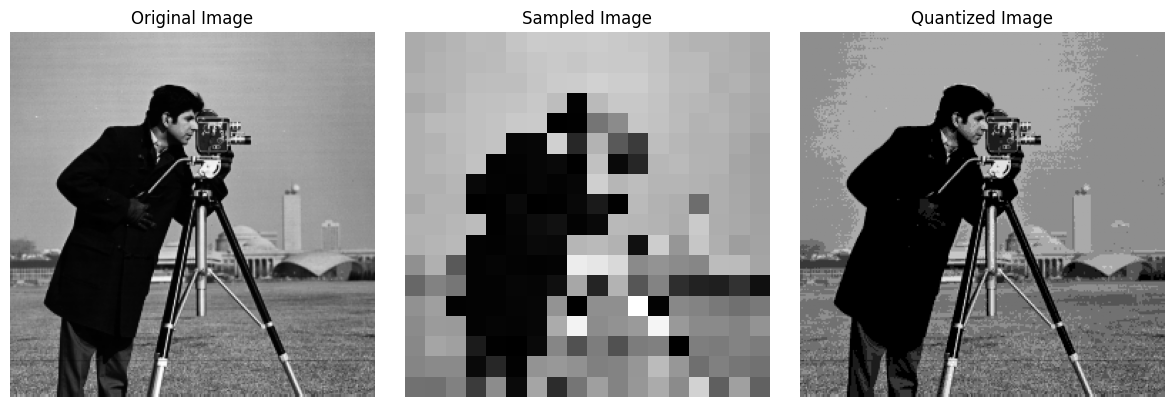

In [15]:
image_path = 'images/cameraman.tif'
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

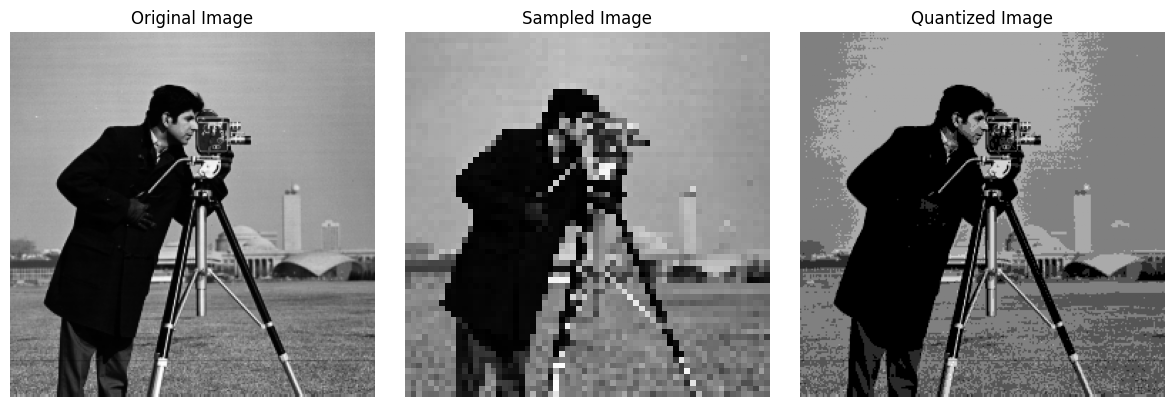

In [ ]:
# Task 1: Change the sampling and quantization parameters and observe the effects
sampled_image = sample_image(original_image, 4)
quantized_image = quantize_image(original_image, 2)

plot_images(original_image, sampled_image, quantized_image)

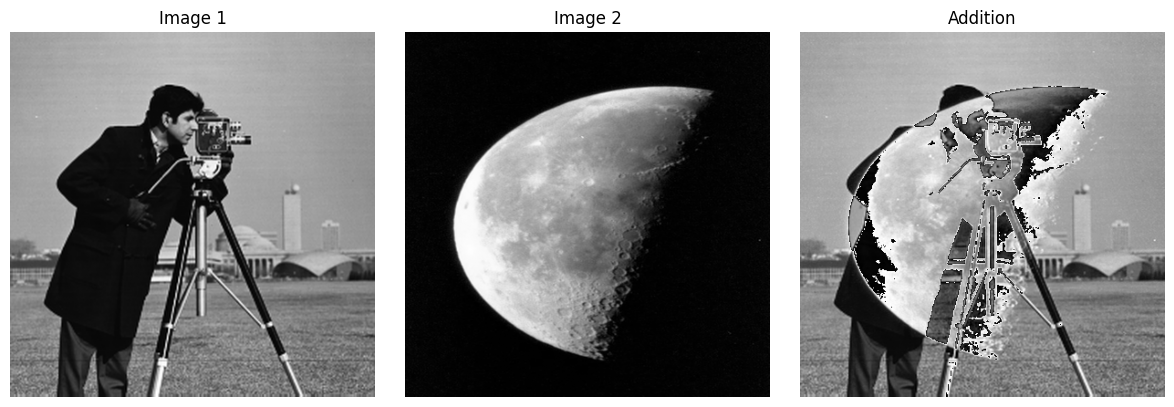

In [25]:
# Arithmetic Operations
img1 = Image.open('images/cameraman.tif')
img2 = Image.open('images/moon.tif')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
resultImage = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(im1arr, cmap='gray')
plt.title('Image 1')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(im2arr, cmap='gray')
plt.title('Image 2')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(np.array(resultImage), cmap='gray')
plt.title('Addition')
plt.axis('off')
plt.tight_layout()
plt.show()

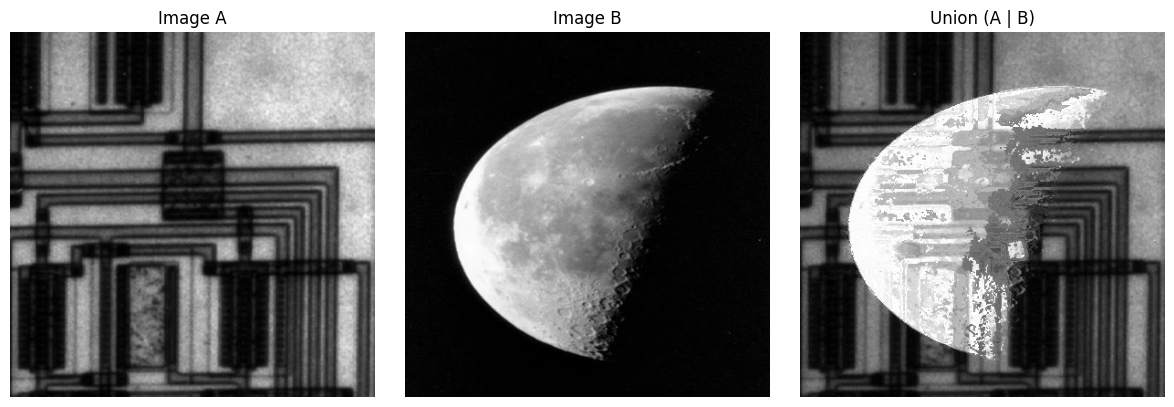

In [27]:
# Sets and Logical Operations
img3 = Image.open('images/circuit.tif')
img4 = Image.open('images/moon.tif')

resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
resultImage2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(im3arr, cmap='gray')
plt.title('Image A')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(im4arr, cmap='gray')
plt.title('Image B')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(np.array(resultImage2), cmap='gray')
plt.title('Union (A | B)')
plt.axis('off')
plt.tight_layout()
plt.show()

[]

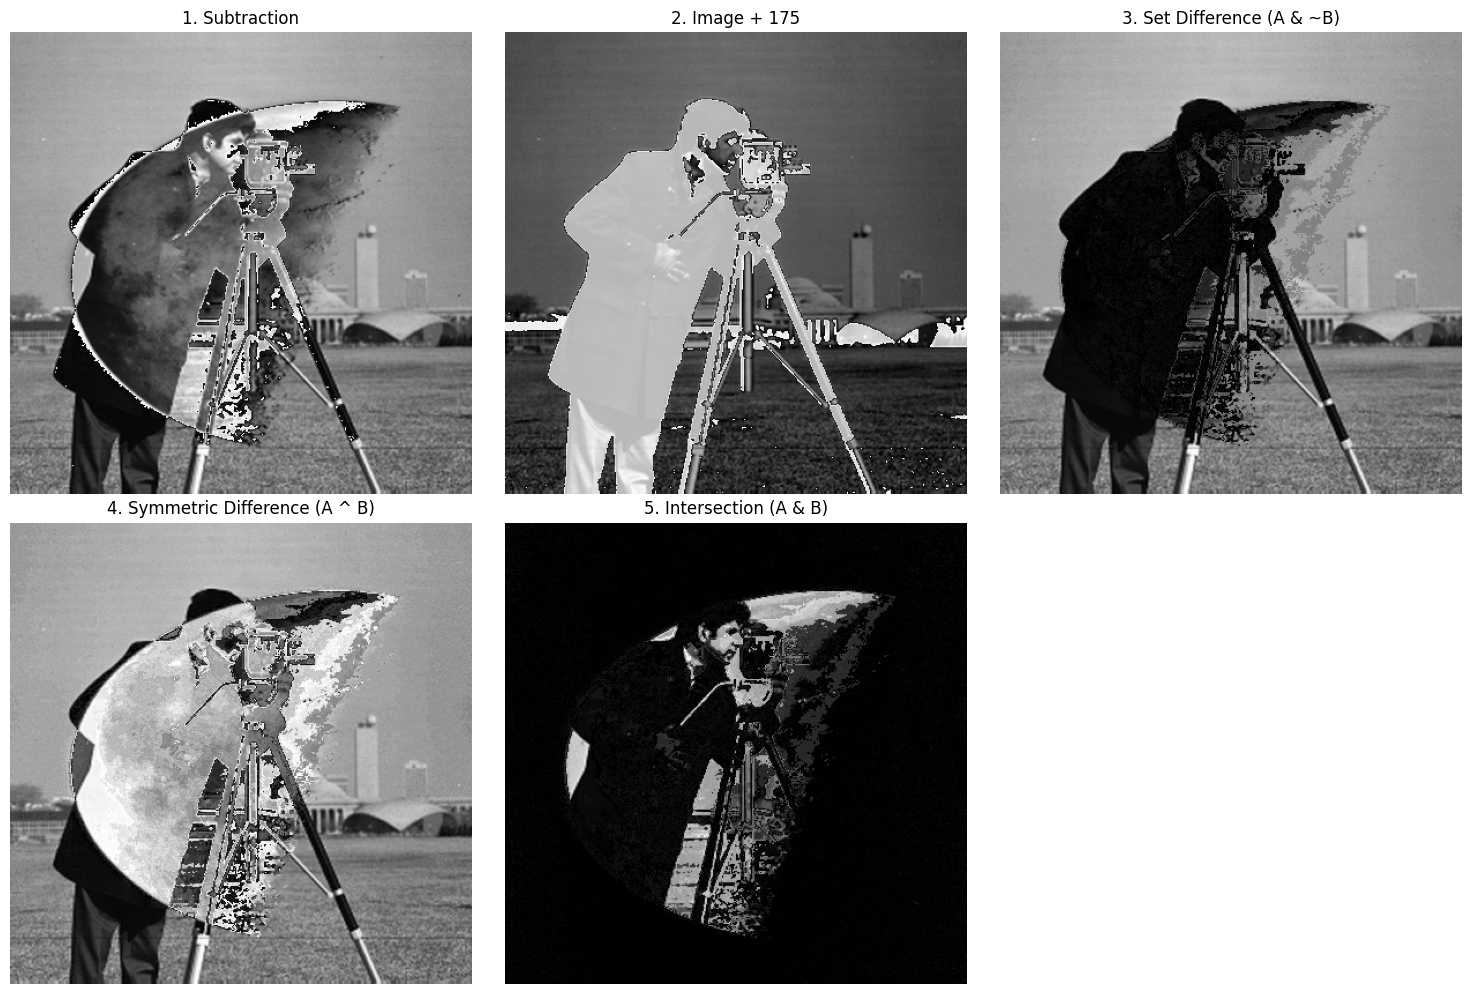

In [28]:
# Task 2: Read two images, convert them into an array, and perform operations
img1 = Image.open("images/cameraman.tif")
img2 = Image.open("images/moon.tif")

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

# 1. Subtract two images and display the result
subtraction = im1arr - im2arr

# 2. Add one image with a constant value of 175 and display it
add_constant = im1arr + 175

# 3. Apply the set difference operation on two Gray-Scale images
set_diff = im1arr & (~im2arr)

# 4. Apply the symmetric difference operation on two Gray-Scale images
sym_diff = im1arr ^ im2arr

# 5. Apply Intersection operations on two Gray-Scale images
intersection = im1arr & im2arr

# Plot all results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(subtraction, cmap="gray")
axes[0, 0].set_title("1. Subtraction")
axes[0, 0].axis("off")

axes[0, 1].imshow(add_constant, cmap="gray")
axes[0, 1].set_title("2. Image + 175")
axes[0, 1].axis("off")

axes[0, 2].imshow(set_diff, cmap="gray")
axes[0, 2].set_title("3. Set Difference (A & ~B)")
axes[0, 2].axis("off")

axes[1, 0].imshow(sym_diff, cmap="gray")
axes[1, 0].set_title("4. Symmetric Difference (A ^ B)")
axes[1, 0].axis("off")

axes[1, 1].imshow(intersection, cmap="gray")
axes[1, 1].set_title("5. Intersection (A & B)")
axes[1, 1].axis("off")

axes[1, 2].axis("off")
plt.tight_layout()
plt.plot()